
Accuracy Comparsion:
Decision tree accuracy: 0.55
Random forest accuracy: 0.6333333333333333

Decision tree confusion matrix:
 [[16 14]
 [13 17]]

Random forest confusion matrix:
 [[17 13]
 [ 9 21]]


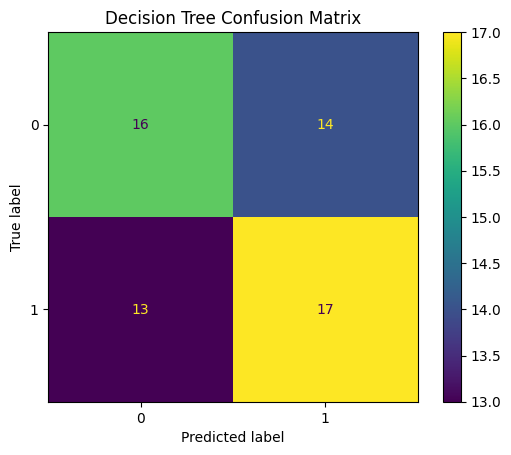

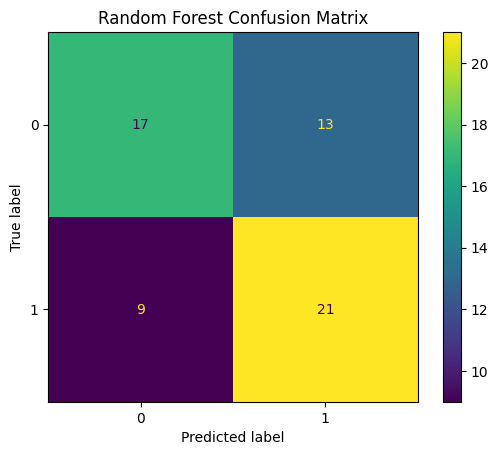


Cross Validation accuracy:
Decision tree: 0.5933333333333334
Random forest: 0.6366666666666666


In [11]:
from numpy.random.mtrand import choice
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay


# generate larger dataset
np.random.seed(42)
random.seed(42)
n_samples=300
data={
    'weather':np.random.choice(['sunny','cloudy','rainy'],n_samples),
    'soil':np.random.choice(['dry','moist','wet'],n_samples),
    'temperature':np.random.choice(['hot','mild','cool'],n_samples),
    'humidity':np.random.choice(['high','medium','low'],n_samples),
    'wind':np.random.choice(['strong','weak'],n_samples),
    'fertilizer':np.random.choice(['yes','no'],n_samples),
    'crop type':np.random.choice(['corn','wheat','rice'],n_samples),
    'season':np.random.choice(['kharif','rabi','summary'],n_samples)
}
df=pd.DataFrame(data)

#Target with Noice
def irrigation_rule(row):
  if row['soil']=='dry'and row['weather']!='rainy':
    base='Yes'
  elif row['soil']=='wet':
    base='No'
  else:
    base=random.choice(['Yes','No'])
  #add noice(flip label with 20% probability)
  if random.random()<0.2:
    return'No' if base=='Yes' else 'Yes'
  return base
df['irrigate']=df.apply(irrigation_rule,axis=1)

le= LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

#split data
X=df.drop('irrigate',axis=1)
Y=df['irrigate']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

#6 decision tree
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,Y_train)
dt_pred_dt=dt_model.predict(X_test)

#random forest
rf_model=RandomForestClassifier(
n_estimators=100,
max_features='sqrt',
random_state=42
)
rf_model.fit(X_train,Y_train)
rf_pred_rf=rf_model.predict(X_test)
y_pred_rf=rf_model.predict(X_test)

#8Accuracy comparsion
dt_acc=accuracy_score(Y_test,dt_pred_dt)
rf_acc=accuracy_score(Y_test,rf_pred_rf)
print("\nAccuracy Comparsion:")
print("Decision tree accuracy:",dt_acc)
print("Random forest accuracy:",rf_acc)

#9confusion matrix
cm_dt=confusion_matrix(Y_test,dt_pred_dt,labels=[0,1])
cm_rf=confusion_matrix(Y_test,y_pred_rf,labels=[0,1])
print("\nDecision tree confusion matrix:\n",cm_dt)
print("\nRandom forest confusion matrix:\n",cm_rf)

#10visual confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_test,dt_pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(Y_test,y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

#11 cross validation
dt_cv=cross_val_score(dt_model,X,Y,cv=5)
rf_cv=cross_val_score(rf_model,X,Y,cv=5)
print("\nCross Validation accuracy:")
print("Decision tree:",dt_cv.mean())
print("Random forest:",rf_cv.mean())